In [1]:
import pandas as pd
import re
from pprint import pprint
import numpy as np
from geopy.geocoders import Nominatim
import reverse_geocode
import uuid
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

cgg_path = r'data/cgg_clean_lat_lon.tsv'
cgg_df_orig = pd.read_csv(cgg_path, sep='\t', dtype=str)

ModuleNotFoundError: No module named 'geopy'

# Geodecoding and more

Functions

In [3]:
def plot_coods(lats, lons):
    # Create a map
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([-180, 180, -90, 90])  # Global view

    # Add features
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.COASTLINE)

    # Plot points
    ax.scatter(lons, lats, color='blue', marker='v', s=200, transform=ccrs.PlateCarree())

    plt.show()

In [4]:
cgg_df = cgg_df_orig.copy()

Decode country from lat and lon using reverse_geocode

In [5]:
def reverse_geocode_decode(row):
    latitude = float(row.converted_lat)
    longitude = float(row.converted_lon)
    
    if pd.notna(latitude) and pd.notna(longitude):
        return reverse_geocode.search([(latitude, longitude)])[0]['country']
    else:
        return np.nan


cgg_df['Country_reverse_geocode'] = cgg_df.apply(reverse_geocode_decode, axis=1)

In [6]:
cgg_df['Country_reverse_geocode'].unique()

array([nan, 'United States', 'Russian Federation', 'Denmark', 'Greenland',
       'Spain', 'Israel', 'Iran, Islamic Republic of', 'China',
       'United Kingdom', 'Chile', 'Iceland', 'Thailand', 'Colombia',
       'Netherlands', 'Croatia', 'Sweden', 'Svalbard and Jan Mayen',
       'Canada', 'New Zealand', 'Germany', 'Estonia', 'Poland', 'Finland',
       'Portugal', 'Egypt', 'Bulgaria', 'Serbia', 'Malaysia',
       'Czech Republic', 'Greece', 'Norway', 'Iraq', 'Cyprus', 'Turkey',
       'France', 'Uzbekistan', 'Ethiopia', 'Kenya', 'Oman', 'Suriname',
       'Italy', 'Albania', 'Saint Pierre and Miquelon'], dtype=object)

Rename some weird reverse_geocode names

In [7]:
cgg_df.Country_reverse_geocode = (
    cgg_df.Country_reverse_geocode
    .replace('Russian Federation', 'Russia')
    .replace('Svalbard and Jan Mayen', 'Svalbard')
    .replace('Iran, Islamic Republic of', 'Iran')
    .replace('United States', 'USA')
    )

Clean the manually inputted country entries

In [8]:
cgg_df.Country = cgg_df.Country.str.strip()

In [9]:
sorted(cgg_df.Country.astype(str).str.strip().unique().tolist())

['Albania',
 'Anartic',
 'Antarctica',
 'Atlantic Ocean',
 'Australia',
 'Austria',
 'Austria?',
 'Belgium',
 'Bulgaria',
 'Canada',
 'Chile',
 'China',
 'Colombia',
 'Columbia',
 'Croatia',
 'Czech Republic',
 'DENMARK',
 'Denmark',
 'Estonia',
 'Ethiopia',
 'Finland',
 'France',
 'Germany',
 'Gibraltar',
 'Great Britain',
 'Greece',
 'Greenland',
 'Greenland?',
 'Hungary',
 'Iceland',
 'Iran',
 'Iraq',
 'Island',
 'Israel',
 'Italy',
 'Japan',
 'Jordan',
 'Laos',
 'Malaysia',
 'Mexico',
 'Netherlands',
 'New Zealand',
 'New Zealand?',
 'Nigeria',
 'North Atlantic',
 'North Pole',
 'Norway',
 'Oman',
 'Outer Mongolia',
 'Poland',
 'Portugal',
 'Qatar',
 'Russia',
 'S America',
 'Serbia',
 'Slovakia',
 'South Africa',
 'Spain',
 'Sweden',
 'Søjleprøve Monolith fra profil 5',
 'Tajikistan',
 'Tanzania',
 'Thailand',
 'The Netherlands',
 'Turkey?',
 'UK',
 'UK?',
 'US',
 'USA',
 'United Kingdom',
 'Uruguay',
 'Uzbekistan',
 'nan',
 '|Denamrk']

In [10]:
cgg_df['Country_cleaned'] = (
    cgg_df.Country
    .replace('Anartic', 'Antarctica')
    .replace('Austria?', 'Austria')
    .replace('Columbia', 'Colombia')
    .replace('DENMARK', 'Denmark')
    .replace('Great Britain', 'United Kingdom')
    .replace('Greenland?', 'Greenland')
    .replace('Island', 'Iceland')
    .replace('New Zealand?', 'New Zealand')
    .replace('Outer Mongolia', 'Mongolia')
    .replace('The Netherlands', 'Netherlands')
    .replace('Turkey?', 'Turkey')
    .replace('UK', 'United Kingdom')
    .replace('UK?', 'United Kingdom')
    .replace('US', 'USA')
    .replace('|Denamrk', 'Denmark')
    )

weird_country_entries = ['S America', 'Søjleprøve Monolith fra profil 5'] 

Check any countries that have a different reported country than the reverse geocoded one

In [11]:
cols = ['Country_reverse_geocode',
       'Country_cleaned', 'Country',
       'converted_lat', 'Lat', 'converted_lon', 'Lon']

bad_countries = {}

for country in (cgg_df
                .query('Country_reverse_geocode != Country_cleaned')
                .dropna(subset=['Country_reverse_geocode', 'Country_cleaned'])[cols]
                .Country_cleaned.unique()):
    bad_countries[country] = (cgg_df
 .query('Country_reverse_geocode != Country_cleaned')
 .dropna(subset=['Country_reverse_geocode', 'Country_cleaned'])[cols]
 .query(f'Country_cleaned == "{country}"')).drop_duplicates()

bad_countries.keys()

dict_keys(['Canada', 'Greenland', 'Norway', 'China', 'Chile', 'Tanzania', 'Finland', 'Sweden', 'Iceland', 'Tajikistan', 'France'])

#### Inspect the data that gets mismatches.
Not sure what to do with theses as I dont know if its the coordinate or country entries that are wrong. The Greenland and Norway ones seems to have errors related to wrong use of Excel fill handle.

In [12]:
bad_countries['Canada']

,Country_reverse_geocode,Country_cleaned,Country,converted_lat,Lat,converted_lon,Lon
4,USA,Canada,Canada,64.957279,+64.957279,-163.89267,-163.89267
2540,USA,Canada,Canada,64.896755,+64.896755,-164.310837,-164.310837


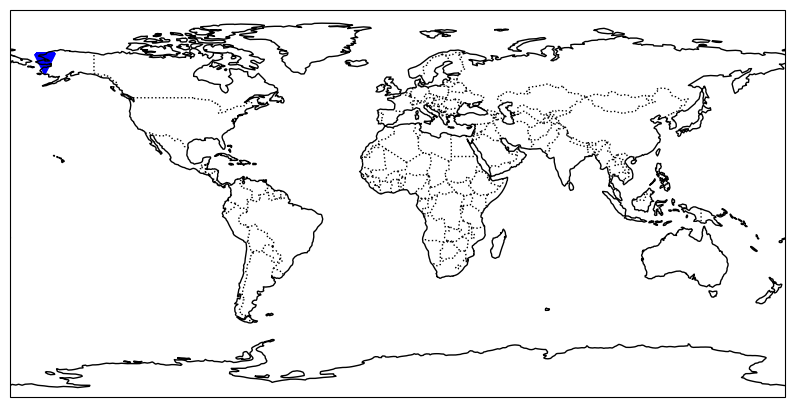

In [13]:
lats = bad_countries['Canada'].converted_lat.astype(float).tolist()
lons = bad_countries['Canada'].converted_lon.astype(float).tolist()   
plot_coods(lats, lons)

In [14]:
bad_countries['Norway']

,Country_reverse_geocode,Country_cleaned,Country,converted_lat,Lat,converted_lon,Lon
1102,Svalbard,Norway,Norway,79.72158333333333,79 43.295 N,10.94705,10 56.823 E
1116,Svalbard,Norway,Norway,78.1027,+78.1027,15.121099,+15.121099
1122,Svalbard,Norway,Norway,78.10283,+78.10283,15.123708,+15.123708
9346,Svalbard,Norway,Norway,79.3382,79.3382˚N,16.019,16.019˚E
9415,Svalbard,Norway,Norway,79.2763,79.2763˚N,16.0785,16.0785˚E
10739,Svalbard,Norway,Norway,77.997,77.99700˚N,14.148,14.14800˚E
12190,Svalbard,Norway,Norway,77.99793,77.99793˚N,14.14862,14.14862˚E
16187,Svalbard,Norway,Norway,70.99085,70.99085,-8.50575,-8.50575
16188,Svalbard,Norway,Norway,70.99088333333333,70.99088333333333,-8.50555,-8.50555
16190,Svalbard,Norway,Norway,70.9909,70.9909,-8.5054,-8.5054


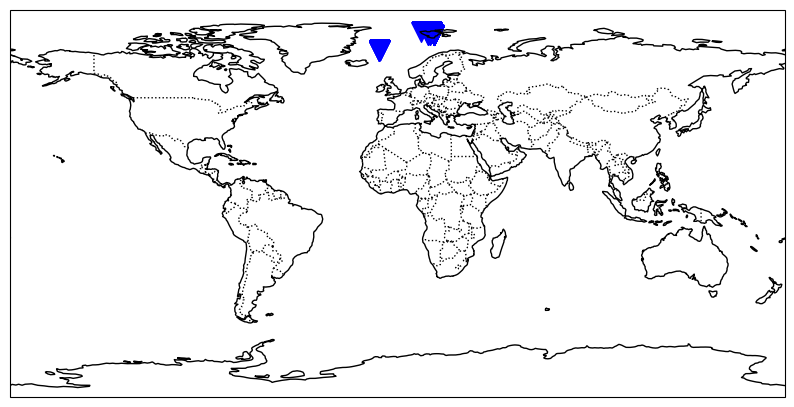

In [15]:
lats = bad_countries['Norway'].converted_lat.astype(float).tolist()
lons = bad_countries['Norway'].converted_lon.astype(float).tolist()   
plot_coods(lats, lons)

In [16]:
bad_countries['Greenland']

,Country_reverse_geocode,Country_cleaned,Country,converted_lat,Lat,converted_lon,Lon
80,Russia,Greenland,Greenland,62.52833333333333,62°31'42'',42.2075,42°12'27''
2560,Canada,Greenland,Greenland,79.89712777777778,"79 53 49,66 N",-64.17422222222223,"64 10 27,2 W"
2561,Canada,Greenland,Greenland,80.89712777777778,"80 53 49,66 N",-65.17422222222223,"65 10 27,2 W"
2562,Canada,Greenland,Greenland,81.89712777777778,"81 53 49,66 N",-66.17422222222223,"66 10 27,2 W"
2563,Canada,Greenland,Greenland,82.89712777777778,"82 53 49,66 N",-67.17422222222223,"67 10 27,2 W"
2564,Canada,Greenland,Greenland,83.89712777777778,"83 53 49,66 N",-68.17422222222223,"68 10 27,2 W"
2565,Canada,Greenland,Greenland,84.89712777777778,"84 53 49,66 N",-69.17422222222223,"69 10 27,2 W"
2567,Canada,Greenland,Greenland,85.89712777777778,"85 53 49,66 N",-70.17422222222223,"70 10 27,2 W"
2568,Canada,Greenland,Greenland,86.89712777777778,"86 53 49,66 N",-71.17422222222223,"71 10 27,2 W"
2569,Canada,Greenland,Greenland,87.89712777777778,"87 53 49,66 N",-72.17422222222223,"72 10 27,2 W"


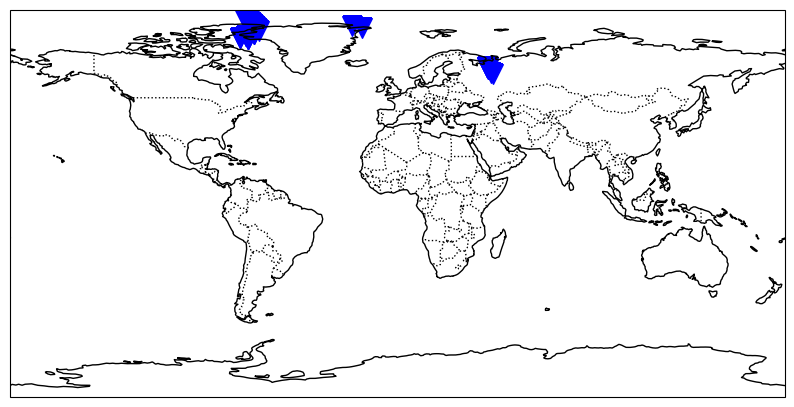

In [17]:
lats = bad_countries['Greenland'].converted_lat.astype(float).tolist()
lons = bad_countries['Greenland'].converted_lon.astype(float).tolist()   
plot_coods(lats, lons)

In [18]:
bad_countries['China']

,Country_reverse_geocode,Country_cleaned,Country,converted_lat,Lat,converted_lon,Lon
7834,Egypt,China,China,28.706211353545,28.706211353545,28.706211353545,28.706211353545
7855,Egypt,China,China,28.7079031641557,28.7079031641557,28.7079031641557,28.7079031641557
7860,Egypt,China,China,28.5701893613775,28.5701893613775,28.5701893613775,28.5701893613775


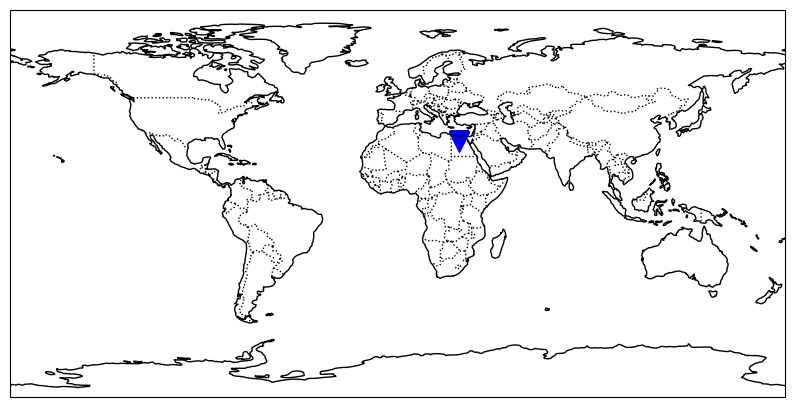

In [19]:
lats = bad_countries['China'].converted_lat.astype(float).tolist()
lons = bad_countries['China'].converted_lon.astype(float).tolist()   
plot_coods(lats, lons)

In [20]:
bad_countries['Chile']

,Country_reverse_geocode,Country_cleaned,Country,converted_lat,Lat,converted_lon,Lon
12431,Uzbekistan,Chile,Chile,40.5695253,40.5695253,73.104309,73.104309


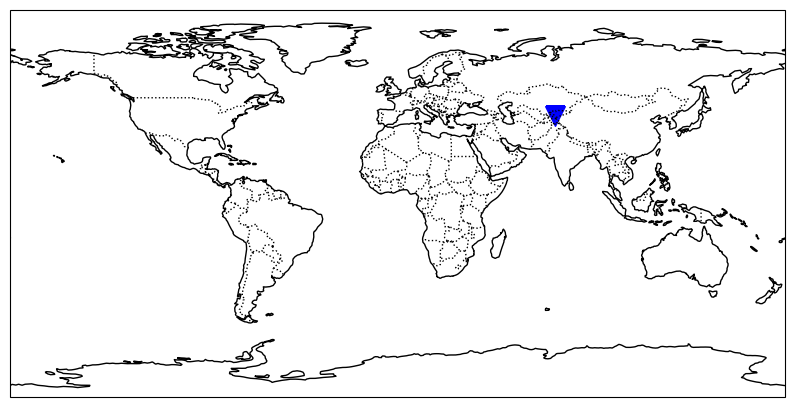

In [21]:
lats = bad_countries['Chile'].converted_lat.astype(float).tolist()
lons = bad_countries['Chile'].converted_lon.astype(float).tolist()   
plot_coods(lats, lons)

In [22]:
bad_countries['Iceland']

,Country_reverse_geocode,Country_cleaned,Country,converted_lat,Lat,converted_lon,Lon
16599,Finland,Iceland,Iceland,64.14496,64.14496,21.94245,21.94245
17432,Norway,Iceland,Iceland,64.84372,64.84372,13.96865,13.96865
17436,Norway,Iceland,Iceland,64.5119,64.5119,14.107,14.1070
17506,Norway,Iceland,Iceland,64.84967,64.84967,13.99852,13.99852
17560,Norway,Iceland,Iceland,64.84371,64.84371,13.96864,13.96864


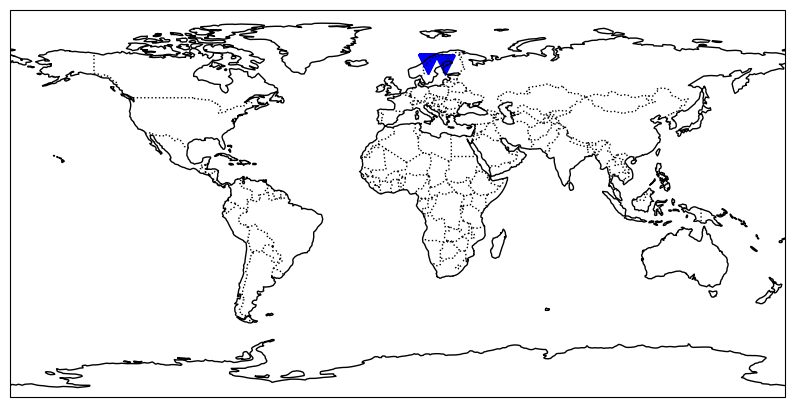

In [23]:
lats = bad_countries['Iceland'].converted_lat.astype(float).tolist()
lons = bad_countries['Iceland'].converted_lon.astype(float).tolist()   
plot_coods(lats, lons)

In [24]:
bad_countries['Tanzania']

,Country_reverse_geocode,Country_cleaned,Country,converted_lat,Lat,converted_lon,Lon
15580,Kenya,Tanzania,Tanzania,-1.1331944444444444,"1°07'59.5""S",33.97511111111111,"33°58'30.4""E"


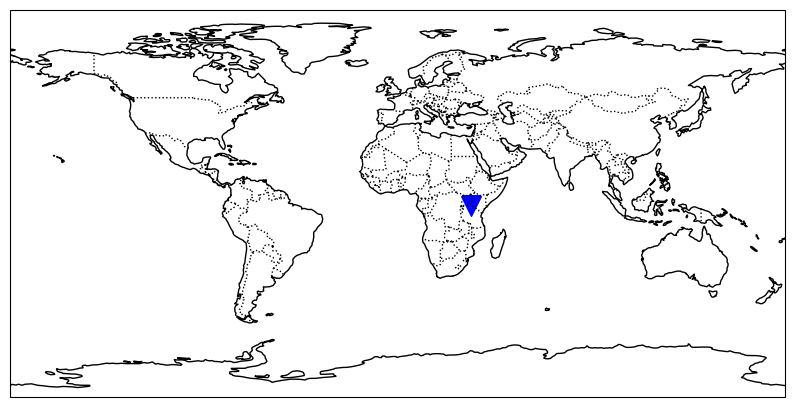

In [25]:
lats = bad_countries['Tanzania'].converted_lat.astype(float).tolist()
lons = bad_countries['Tanzania'].converted_lon.astype(float).tolist()   
plot_coods(lats, lons)

In [26]:
bad_countries['Finland']

,Country_reverse_geocode,Country_cleaned,Country,converted_lat,Lat,converted_lon,Lon
16245,Norway,Finland,Finland,68.885109,68.885109,21.035574,21.035574
16246,Norway,Finland,Finland,68.88514,68.88514,21.035683,21.035683
16247,Norway,Finland,Finland,68.885139,68.885139,21.035905,21.035905
16248,Norway,Finland,Finland,68.885055,68.885055,21.035842,21.035842
16249,Norway,Finland,Finland,68.884979,68.884979,21.035753,21.035753
16250,Norway,Finland,Finland,68.727942,68.727942,21.423515,21.423515
16251,Norway,Finland,Finland,68.72786,68.72786,21.423581,21.423581
16252,Norway,Finland,Finland,68.728015,68.728015,21.423436,21.423436
16253,Norway,Finland,Finland,68.727991,68.727991,21.42339,21.42339
16254,Norway,Finland,Finland,68.727919,68.727919,21.423705,21.423705


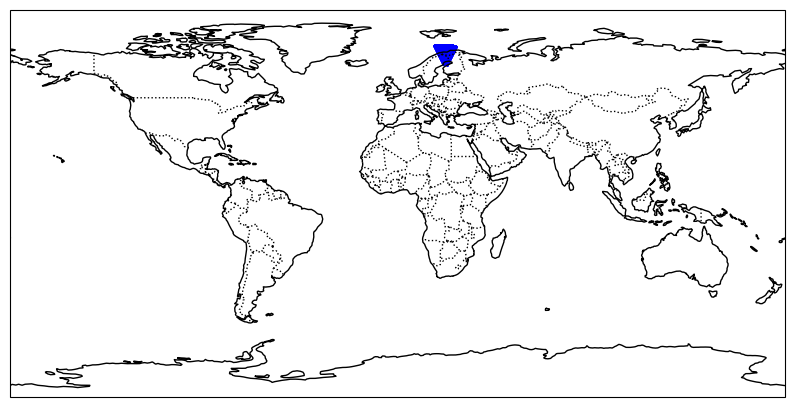

In [27]:
lats = bad_countries['Finland'].converted_lat.astype(float).tolist()
lons = bad_countries['Finland'].converted_lon.astype(float).tolist()   
plot_coods(lats, lons)

In [28]:
bad_countries['Sweden']

,Country_reverse_geocode,Country_cleaned,Country,converted_lat,Lat,converted_lon,Lon
16255,Norway,Sweden,Sweden,68.350655,68.350655,22.172485,22.172485
16256,Norway,Sweden,Sweden,68.350793,68.350793,22.172441,22.172441
16257,Norway,Sweden,Sweden,68.350805,68.350805,22.172143,22.172143
16258,Norway,Sweden,Sweden,68.350647,68.350647,22.172725,22.172725
16259,Norway,Sweden,Sweden,68.350538,68.350538,22.172427,22.172427
18612,Norway,Sweden,Sweden,68.44222,68.44222˚N,18.57761,18.57761˚E
18622,Norway,Sweden,Sweden,68.45137,68.45137˚N,18.57241,18.57241˚E
18632,Norway,Sweden,Sweden,68.44777,68.44777˚N,18.13128,18.13128˚E


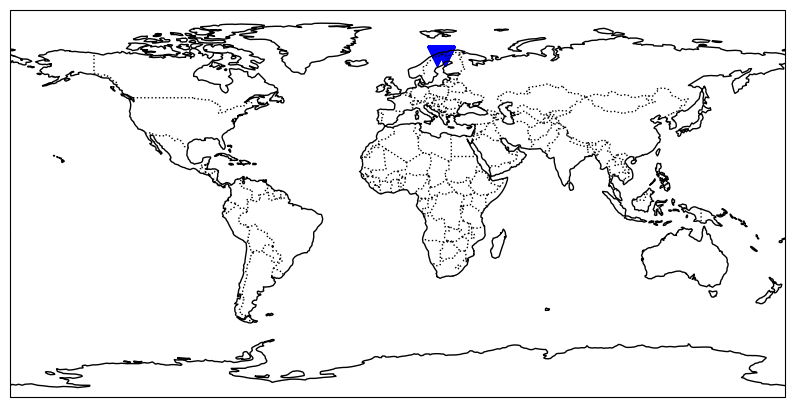

In [29]:
lats = bad_countries['Sweden'].converted_lat.astype(float).tolist()
lons = bad_countries['Sweden'].converted_lon.astype(float).tolist()   
plot_coods(lats, lons)

In [30]:
bad_countries['Tajikistan']

,Country_reverse_geocode,Country_cleaned,Country,converted_lat,Lat,converted_lon,Lon
18418,Russia,Tajikistan,Tajikistan,68.429764,68.429764,38.600373,38.600373
18479,Russia,Tajikistan,Tajikistan,70.046437,70.046437,38.359337,38.359337


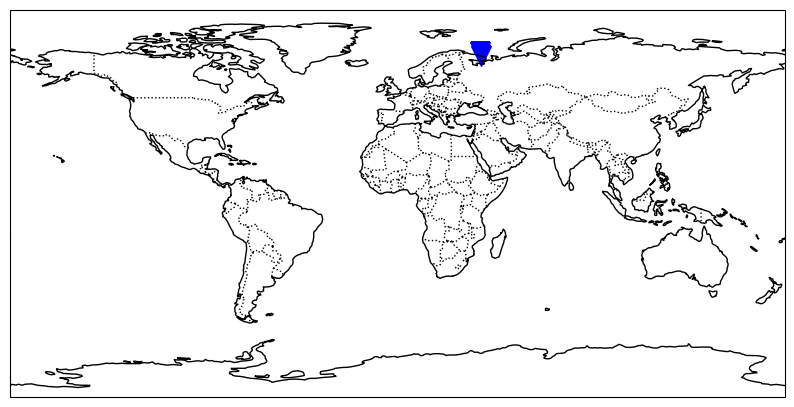

In [31]:
lats = bad_countries['Tajikistan'].converted_lat.astype(float).tolist()
lons = bad_countries['Tajikistan'].converted_lon.astype(float).tolist()   
plot_coods(lats, lons)

In [32]:
bad_countries['France']

,Country_reverse_geocode,Country_cleaned,Country,converted_lat,Lat,converted_lon,Lon
19207,Saint Pierre and Miquelon,France,France,46.82281,46.82281˚N,-56.18042,56.18042˚W


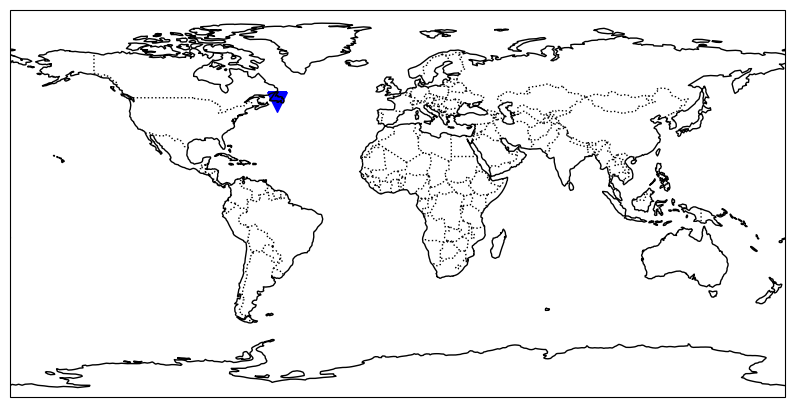

In [33]:
lats = bad_countries['France'].converted_lat.astype(float).tolist()
lons = bad_countries['France'].converted_lon.astype(float).tolist()   
plot_coods(lats, lons)

### Check for errors related to fill handle

In [34]:
cgg_df['converted_lon'] = cgg_df['converted_lon'].astype(float)
cgg_df['converted_lat'] = cgg_df['converted_lat'].astype(float)

In [35]:
cgg_df['lat_diffs_flag'] = (((cgg_df['converted_lat'] - cgg_df['converted_lat'].shift(1)).abs() == 1) | 
                            ((cgg_df['converted_lat'] - cgg_df['converted_lat'].shift(-1)).abs() == 1))  # Returns true if the previous or subsequent value is -1 or +1
cgg_df['lon_diffs_flag'] = (((cgg_df['converted_lon'] - cgg_df['converted_lon'].shift(1)).abs() == 1) | 
                            ((cgg_df['converted_lon'] - cgg_df['converted_lon'].shift(-1)).abs() == 1)) 

Below is shown how many rows might have this error

In [38]:
len(cgg_df.query('lat_diffs_flag == True | lon_diffs_flag == True')[['cgg_id', 'Museum ID/sample ID', 'converted_lat']].sort_values(by='cgg_id'))

27

Update the data_cleaning_note where theses errors occur

In [39]:
update_filter = (cgg_df["lat_diffs_flag"] == True) | (cgg_df["lon_diffs_flag"] == True)
cgg_df.loc[update_filter, 'data_cleaning_note'] = 'Needs human validation'

#### Stats

 How many mismatces between reported Country and decoded Country (out of all entries that has a reported Country and that does not have invalid formats):

In [40]:
len(cgg_df
    .dropna(subset=['Country_reverse_geocode', 'Country_cleaned'])
    .query('Country_reverse_geocode != Country_cleaned'))

1023

Flag the ones that needs human validation

In [ ]:
update_filter = (cgg_df["Country_reverse_geocode"] != cgg_df["Country_cleaned"]) & (~cgg_df["Country_reverse_geocode"].isna()) & (~cgg_df["Country_cleaned"].isna())
cgg_df.loc[update_filter, 'data_cleaning_note'] = 'Needs human validation'

Total amount of Lat Lon entreis that needs human validation:

In [ ]:
len(cgg_df.query("data_cleaning_note == 'Needs human validation'"))

10348

### Clean names

### Clean depositional environment

In [ ]:
allowed_envs = ['lacustrine',
'unknown',
'glaciofluvial',
'terrestrial',
'marine',
'bog',
'glacial',
'midden',
'aeolian',
'Contact Jesper for a new more suitable value',
'archaeological context',
'permafrost',
'deltaic',
'fluvial',
'soil',
'sediment']

In [ ]:
cgg_df['Depositional environment_clean'] = None

In [ ]:
sorted(cgg_df['Depositional environment'].dropna().astype(str).unique().tolist())

['18th -19th century reclaimation fill+underlying marine sequence',
 '?',
 'A2 lag 1, MP 139.',
 'A2 lag 19.  Profil 5. MP 138.',
 'A2 lag 26 til MP 140.',
 'A2 lag 38, profil 5 ved MP 141.',
 'Alluvium/mixed',
 'Ancient lake',
 'Archaeological',
 'Archaeological site',
 'Archaeoogical layers',
 'Archaoelogical/ aluvial terrace',
 'Archeological',
 'Arctic lake',
 'Associated with Arlington Springs (CA-SRI-173) burial',
 'Basal glacier sediments',
 'Brecciated Cave cut from Pleistocene lake wave action. Deposits are post last inundation (circa 14000cal BP) and are largely formed from aeolian deposits and rockfall/cave erosion.',
 'Bronze Age pit deposit',
 'CONTROL: Sterile sand underneath the construction of the mound.',
 'Cave sediment',
 'Clay',
 'Colluvial',
 'Cultural',
 'Cultural layer with pottery, lithics, land animal bones and botanical remains',
 'Dense peat',
 'Edge of outflow for Pleistocene age springfed wetlands, site is currently dessicated',
 'Fill from base of burial (

In [ ]:
sorted(cgg_df['Material type'].dropna().astype(str).unique().tolist())

['116-126',
 '117-127',
 '120-130',
 '693.18 m MASL',
 'Anthropogenic sediments',
 'Archaeological sediment',
 'Area 1, Trench 1, filling along the northern edge of Feature 2',
 'Area 1, Trench 1, filling north-west of Feature 2',
 'Area 1, Trench 1, supposed soil contain offer-disposal west of Feature 2',
 'Area 1, Trench 6, test from Profile 6/trench 6 north of Feature 2',
 'Bat guano',
 'Bone Fragments',
 'Charred sediment',
 'Charred soil',
 "Collector's DNA",
 'Coprolite',
 'DNA extraction',
 'Diatome gyttja',
 'Dung',
 'Dunghill',
 'Extract',
 'Fecal',
 'Filteret Water',
 'From base of grave beneith crania (aprox.)',
 'From the center of the grave above and including the layer of decomposed wood',
 'From the center of the grave beneith the layer of decomposed wood',
 'Glacial Rock flour',
 'Gytja',
 'Gyttja',
 'Ice',
 'Ice core',
 'Ice core sediment',
 'Ice samples',
 'Konkretion sediment Fe-oxid',
 'Kryokonit',
 'Lake gyttja',
 'Lake sediment',
 'Late Neolithic-Early Chalcolithi

### Clean age

In [ ]:
cgg_df['Age_cleaned'] = (cgg_df.Age
                        .map(lambda x: re.sub(r'\s+', ' ', x), na_action='ignore')  # Removes any consecutive whitespaces
                        .map(lambda x: x.replace(u'\xa0', u' '), na_action='ignore')  # Fix  weird unicode error
                        .map(lambda x: x.lower().strip(), na_action='ignore')  # Fix  weird unicode error
                        .map(lambda x: re.sub(r'[–—]', '-', x), na_action='ignore')  # Fix  weird unicode error
                        .map(lambda x: x.lower().strip(), na_action='ignore')  # Fix  weird unicode error
                        .map(lambda x: x.lower().strip(), na_action='ignore')  # Fix  weird unicode error
                        .map(lambda x: x.replace('+/-', '±'), na_action='ignore')
                        .map(lambda x: x.replace('-/+', '±'), na_action='ignore')
                        .map(lambda x: x.replace('+-', '±'), na_action='ignore')
                        .map(lambda x: x.replace('-+', '±'), na_action='ignore')
                        .map(lambda x: x.replace('»', '>'), na_action='ignore')
                        .map(lambda x: re.sub(r'\bca\b\.?', '~', x), na_action='ignore')               
                        .map(lambda x: re.sub(r'\bcirka\b', '~', x), na_action='ignore')               
                        .map(lambda x: re.sub(r'\bcirca\b', '~', x), na_action='ignore')               
                        .map(lambda x: re.sub(r'\bapprox\b\.?', '~', x), na_action='ignore')               
                        .map(lambda x: re.sub(r'\bapproximately\b', '~', x), na_action='ignore')               
                        .map(lambda x: re.sub(r'\baproximately\b', '~', x), na_action='ignore')               
                        .map(lambda x: re.sub(r'\baprox\b\.?', '~', x), na_action='ignore')               
                        .map(lambda x: re.sub(r'\baround\b', '~', x), na_action='ignore')               
                        .map(lambda x: re.sub(r'\band\b', '&', x), na_action='ignore')               
                        .map(lambda x: re.sub(r'\bto\b', '-', x), na_action='ignore')               
                        .map(lambda x: re.sub(r'\byrs\b', 'years', x), na_action='ignore')               
                        .map(lambda x: re.sub(r'\byr\b', 'years', x), na_action='ignore')               
                        .map(lambda x: re.sub(r'\bår\b', 'years', x), na_action='ignore')               
                        ) 

In [ ]:
unit_pattern = r'\b(bp|bc|ad|bce|ce|ka|kyr|mya|ma|år|yrs|century|circa|ca\.?)\b'

In [ ]:
cgg_df['Age_type'] = ''

Mark all ages that do not have a number as Categorical and all that has a number as Numerical

In [ ]:
update_filter = cgg_df['Age_cleaned'].str.contains(r'\d', regex=True, na=False)
cgg_df.loc[~update_filter, 'Age_type'] = 'Categorical'
cgg_df.loc[update_filter, 'Age_type'] = 'Numerical'

In [ ]:
numerical_filter = (cgg_df.Age_type == 'Numerical')
error_filter = numerical_filter & (cgg_df.Age_cleaned.str.contains('±'))

cgg_df[numerical_filter]['Age_cleaned']

0          between 1-10500bp
1          between 1-10500bp
2          between 1-10500bp
3          between 1-10500bp
4          between 1-10500bp
                ...         
20687    18th - 17th century
20688    18th - 17th century
20689    18th - 17th century
20690    18th - 17th century
20691    18th - 17th century
Name: Age_cleaned, Length: 5025, dtype: object

Only get letters from the numerical Ages

In [ ]:


single = ['12 ± 12',
 '12 ± 12 bp',
 '12 ± 12 rcybp',
 '12 ±12',
 '12 ±12 rcybp',
 '12± 12',
 '12±12',
 '12±12 bp, cremated bones from sec.burial.id 12-12 cal bc (12,12 % prob.)',
 'c12: 12± 12']

#  General
error_pattern = r'\d+ ? ± ?\d+ ?[a-z]*'

multiple = [
    '12±12 12± 12 bp',
    '12 ± 12 12 ± 12',
    '12±12 12± 12',
    '12±12 12',
    '12 ± 12; 12 ± 12 bp',
    '12 ± 12, 12 ± 12',
]

In [ ]:
sorted(cgg_df[error_filter]['Age_cleaned'].map(lambda x: re.sub(r'\d+', '12', x), na_action='ignore').unique())

['12 ± 12',
 '12 ± 12 12 ± 12',
 '12 ± 12 bp',
 '12 ± 12 rcybp',
 '12 ± 12, 12 ± 12',
 '12 ± 12; 12 ± 12 bp',
 '12 ±12',
 '12 ±12 rcybp',
 '12± 12',
 '12±12',
 '12±12 12',
 '12±12 12± 12',
 '12±12 12± 12 bp',
 '12±12 bp, cremated bones from sec.burial.id 12-12 cal bc (12,12 % prob.)',
 'c12: 12± 12']

In [ ]:
s = (cgg_df[numerical_filter]['Age_cleaned']
       .map(lambda x: re.sub(r'[^a-zA-Z ]', '', x), na_action='ignore')
       .str.strip()
       .str.split(' '))

unique_values = list({item for sublist in s for item in sublist})


In [ ]:
sorted(unique_values)

['',
 'a',
 'ad',
 'after',
 'age',
 'ago',
 'at',
 'awaiting',
 'based',
 'bayesian',
 'bc',
 'bce',
 'before',
 'below',
 'between',
 'bones',
 'bp',
 'bronze',
 'burial',
 'but',
 'c',
 'cal',
 'calibrated',
 'ce',
 'century',
 'contemporary',
 'cremated',
 'date',
 'dated',
 'dates',
 'detail',
 'e',
 'early',
 'eemian',
 'finds',
 'first',
 'from',
 'grave',
 'hallstat',
 'iron',
 'k',
 'ka',
 'ky',
 'kya',
 'kyr',
 'last',
 'latest',
 'layer',
 'ma',
 'metal',
 'mice',
 'modelling',
 'more',
 'myr',
 'ndrd',
 'neolithic',
 'nordic',
 'of',
 'on',
 'period',
 'present',
 'prob',
 'radiocarbon',
 'range',
 'rc',
 'rcybp',
 'result',
 'roman',
 's',
 'scand',
 'secburialid',
 'secondary',
 'site',
 'strd',
 'th',
 'the',
 'with',
 'years',
 'yrs']

In [ ]:
ages = sorted(cgg_df[numerical_filter]['Age_cleaned']
       .map(lambda x: re.sub(r'\d+', '12', x), na_action='ignore')
       .map(lambda x: re.sub(r'[\da-zøæå]', '', x), na_action='ignore')
       .str.replace(' ', '')
       .unique())

In [ ]:
unique_chars = set()

# Loop through each string and update the set with matches
for s in ages:
    matches = re.findall(r'[^A-Za-z0-9]', s)
    unique_chars.update(matches)

In [ ]:

ages

['',
 '&',
 "'?",
 '()',
 '(-);',
 '(~)',
 '(~-),',
 ',',
 ',(-).',
 ',.',
 '-',
 '-()',
 '-(-)',
 '-(.%);-(.%)()',
 '-,',
 '-,~',
 '-.',
 '-.?',
 '-/',
 '-/-',
 '-?',
 '.',
 '.-',
 '.-.',
 './.',
 '.?',
 '/',
 ':±',
 '>',
 '?',
 '~',
 '~-',
 '~-?',
 '~.',
 '~.(?)',
 '~..',
 '~/',
 '~?',
 '±',
 '±,..-(,%.)',
 '±,±',
 '±;±',
 '±±',
 '≥.<~.']

In [ ]:
ages

['',
 '&',
 "'?",
 '()',
 '(-);',
 '(~)',
 '(~-),',
 ',',
 ',(-).',
 ',.',
 '-',
 '-()',
 '-(-)',
 '-(.%);-(.%)()',
 '-,',
 '-,~',
 '-.',
 '-.?',
 '-/',
 '-/-',
 '-?',
 '.',
 '.-',
 '.-.',
 './.',
 '.?',
 '/',
 ':±',
 '>',
 '?',
 '~',
 '~-',
 '~-?',
 '~.',
 '~.(?)',
 '~..',
 '~/',
 '~?',
 '±',
 '±,..-(,%.)',
 '±,±',
 '±;±',
 '±±',
 '≥.<~.']

In [ ]:
unique_chars

{'%',
 '&',
 "'",
 '(',
 ')',
 ',',
 '-',
 '.',
 '/',
 ':',
 ';',
 '<',
 '>',
 '?',
 '~',
 '±',
 '≥'}